<a href="https://colab.research.google.com/github/Artem1965/DS23_Module3_Assignment1_Supervised_Learning/blob/main/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Exploratory Data Analysis

In [20]:
import sys, os, pandas as pd
if not os.path.exists("/content/repo"):
    get_ipython().system('git clone -b artem-dev https://github.com/romankli/Energy-optimization-for-desalination-plant.git /content/repo')
PROJECT_ROOT = "/content/repo"
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
from src.Util import *
print("Util imported successfully.")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

Cloning into '/content/repo'...
fatal: could not read Username for 'https://github.com': No such device or address
Util imported successfully.


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Data & Overview

In [9]:
# https://drive.google.com/file/d/1C9IGzfJ0xN07fQCri6iQs0k-_1W31iKb/view?usp=drive_link
# Upload data from Google Drive
file_id = "1C9IGzfJ0xN07fQCri6iQs0k-_1W31iKb"
url = f"https://drive.google.com/uc?id={file_id}"
df = pd.read_csv(url)
"""
Upload from local folder
csv_path = os.path.join(os.getcwd(), '..', 'data', 'raw', 'Desalination plant report 19.3.26-14.6.26.csv')
df = pd.read_csv(csv_path)
print(f"Loaded: {csv_path}")
"""
# Display shape, column list, head, info, describe(include='all'), memory
#basic_info_dict = basic_info(df)

'\nUpload from local folder\ncsv_path = os.path.join(os.getcwd(), \'..\', \'data\', \'raw\', \'Desalination plant report 19.3.26-14.6.26.csv\')\ndf = pd.read_csv(csv_path)\nprint(f"Loaded: {csv_path}")\n'

## Full Report

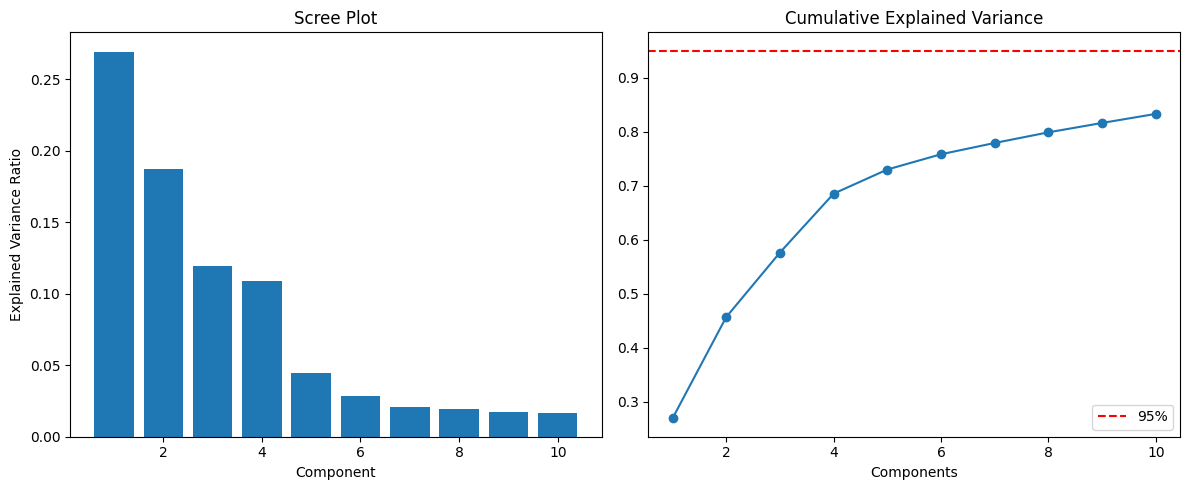

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
Pressure after source-water well pumps (Bar),0.111591,-0.082651,0.078467,0.002656,0.080712,-0.230942,0.000619,-0.092977,-0.081718,0.256263
Pressure after booster pumps (Bar),0.164696,0.014599,0.022770,-0.022729,0.324396,0.019592,0.119850,-0.028815,0.065581,-0.075580
Flow from wells line 2 FIT_200_201 (m^3/h),0.050213,0.054913,-0.033488,-0.319691,-0.039581,-0.012464,0.032551,0.023894,0.022887,-0.073907
Pressure from wells line 2 PIT_200_201 (Bar),0.003148,0.003989,0.014948,0.230119,0.082414,0.093599,-0.101016,-0.252773,-0.121597,0.042844
Flow from wells line 1 FIT_200_101 (m^3/h),0.214327,0.058536,-0.034070,0.017081,-0.000812,-0.039195,0.013144,-0.007903,-0.007140,0.019564
...,...,...,...,...,...,...,...,...,...,...
Water temperature AIT_500_506 C,0.045437,0.065670,-0.059158,-0.132745,0.023899,0.380649,0.002233,0.092646,0.179398,-0.014274
CIP tank Level LIT_600_601 %,0.105276,-0.044769,0.086982,-0.007119,0.175457,-0.161728,0.125653,0.096012,-0.227682,0.119921
Antiscalant Dosing Tank Level LIT_700_101 %,0.026540,0.068025,-0.004805,-0.048954,0.062162,0.420596,-0.087381,-0.175536,-0.125931,0.032182
NaOH Dosing Tank Level LIT_700_301 %,-0.020079,-0.019931,-0.009765,-0.022064,-0.126526,0.145229,0.366108,0.359433,0.082001,0.459145


In [10]:
#full_eda_report(df)
pca_analysis(df)

In [16]:
import inspect
print(inspect.getsource(pca_analysis))

def pca_analysis(df: pd.DataFrame, cols: list = None, n_components: int = 10,
                 figsize: tuple = (12, 5)) -> pd.DataFrame:
    """
    Run PCA, plot a scree chart and cumulative explained variance, return loadings.
    Features are standardized with StandardScaler before PCA.

    Parameters
    df : pd.DataFrame
        The input DataFrame.
    cols : list, optional
        Columns to include. Defaults to all numeric columns.
    n_components : int, optional
        Number of principal components to compute. Default is 10.
    figsize : tuple, optional
        Figure size as (width, height). Default is (12, 5).

    Returns
    pd.DataFrame
        Component loading matrix of shape (n_features, n_components),
        indexed by feature name with columns PC1, PC2, ..., PCn.
    """
    cols = cols or df.select_dtypes(include=np.number).columns.tolist()
    data = df[cols].dropna()
    scaler = StandardScaler()
    scaled = scaler.fit_transform(data)
    n_components = mi

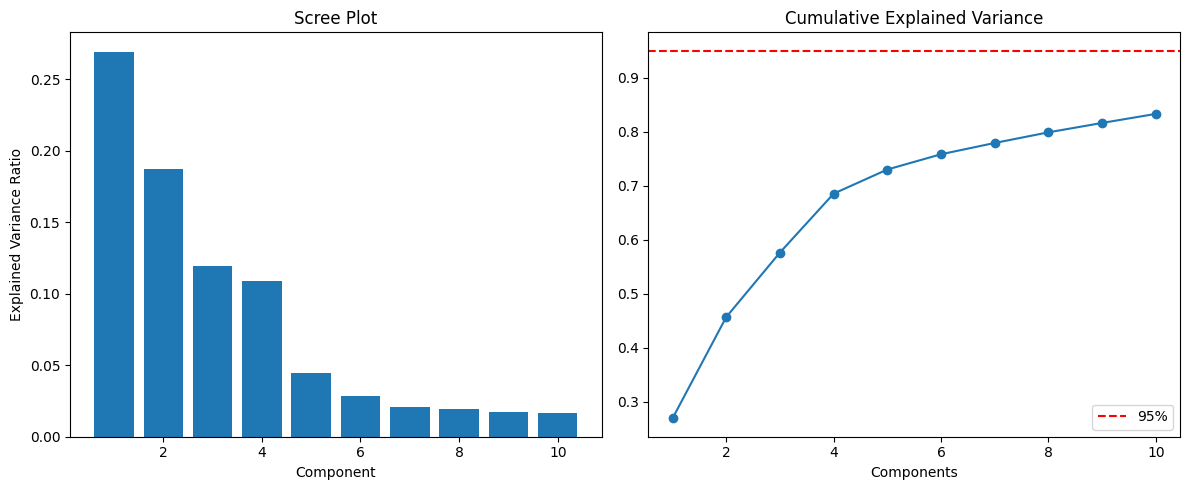

Top 15 features driving PC1:
Flow from wells line 1 FIT_200_101 (m^3/h)                            0.214327
Pressure after booster pumps (Bar)                                    0.164696
Pressure after HP Pump Skid 2 PIT_400_401 (Bar)                       0.163517
DP Stage 1 Skid 2 Calculated (Bar)                                    0.161516
Presure after Stage 2 Brine line Skid 2 PIT_400_405 (Bar)             0.160908
Presure after booster pump before Stage 2 Skid 2 PIT_400_404 (Bar)    0.160833
Presure after stage 1 before booster pump Skid 2 PIT_400_402 (Bar)    0.159784
DP Stage 1 Skid 1 Calculated (Bar)                                    0.151516
Pressure after HP Pump Skid 1 PIT_400_401 (Bar)                       0.149680
Presure after booster pump before Stage 2 Skid 1 PIT_400_404 (Bar)    0.149080
Product Flow Skid 2 Calculated (m^3/h)                                0.148906
Feed Flow Skid 2 Calculated (m^3/h)                                   0.148568
Presure after Stage 2 B

In [18]:
loadings = pca_analysis(df)
top_pc1 = loadings['PC1'].reindex(loadings['PC1'].abs().sort_values(ascending=False).index)
top_pc2 = loadings['PC2'].reindex(loadings['PC2'].abs().sort_values(ascending=False).index)
print('Top 15 features driving PC1:')
print(top_pc1.head(15))
print()
print('Top 15 features driving PC2:')
print(top_pc2.head(15))

In [19]:
top_pc3 = loadings['PC3'].reindex(loadings['PC3'].abs().sort_values(ascending=False).index)
top_pc4 = loadings['PC4'].reindex(loadings['PC4'].abs().sort_values(ascending=False).index)
print('Top 15 features driving PC3:')
print(top_pc3.head(15))
print()
print('Top 15 features driving PC4:')
print(top_pc4.head(15))

Top 15 features driving PC3:
Feed Flow Skid 2 Calculated (m^3/h)                                   0.210964
Product Flow Skid 2 Calculated (m^3/h)                                0.209392
Clean water flow after Stage 1 Skid 2 FIT_400_401 (m^3/h)             0.208992
Clean water flow after Stage 2 Skid 2 FIT_400_402 (m^3/h)             0.206737
Recovery Skid 2 Calculated %                                          0.205545
Brine flow after Stage 2 Skid 2 FIT_400_403 (m^3/h)                   0.203609
DP Stage 2 Skid 2 Calculated (Bar)                                    0.203267
Presure after booster pump before Stage 2 Skid 2 PIT_400_404 (Bar)    0.192244
Pressure after HP Pump Skid 2 PIT_400_401 (Bar)                       0.189170
Presure after Stage 2 Brine line Skid 2 PIT_400_405 (Bar)             0.187453
SKID1_Step                                                           -0.185571
Presure after stage 1 before booster pump Skid 2 PIT_400_402 (Bar)    0.185538
DP Stage 1 Skid 2 Calcu

## Quick Stats

In [11]:
# Extend describe() with skewness, kurtosis, and IQR for all numeric columns
quick_stats(df)

                                                 count        mean  \
Pressure after source-water well pumps (Bar)  114218.0    2.261029   
Pressure after booster pumps (Bar)            114218.0    6.364407   
Flow from wells line 2 FIT_200_201 (m^3/h)    114218.0  134.108196   
Pressure from wells line 2 PIT_200_201 (Bar)  114218.0    4.239321   
Flow from wells line 1 FIT_200_101 (m^3/h)    114218.0  591.466091   
...                                                ...         ...   
Water temperature AIT_500_506 C               114217.0   26.034822   
CIP tank Level LIT_600_601 %                  114217.0   95.281201   
Antiscalant Dosing Tank Level LIT_700_101 %   114217.0   68.868804   
NaOH Dosing Tank Level LIT_700_301 %          114217.0   79.917502   
NaOCl Dosing Tank Level LIT_700_401 %         114217.0   88.507085   

                                                     std         min  \
Pressure after source-water well pumps (Bar)    0.286752    0.000000   
Pressure after 

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,IQR
Pressure after source-water well pumps (Bar),114218.0,2.261029,0.286752,0.000000,2.210000,2.300000,2.370000,3.690000,-6.684700,49.235313,0.160000
Pressure after booster pumps (Bar),114218.0,6.364407,0.396888,2.320000,6.480000,6.500000,6.510000,8.280000,-5.745182,42.538571,0.030000
Flow from wells line 2 FIT_200_201 (m^3/h),114218.0,134.108196,73.647257,-0.397859,79.752602,149.233215,181.676788,290.147583,-0.376505,-0.678692,101.924187
Pressure from wells line 2 PIT_200_201 (Bar),114218.0,4.239321,0.559120,1.070240,3.863571,4.181496,4.484954,6.696687,0.836319,1.337965,0.621383
Flow from wells line 1 FIT_200_101 (m^3/h),114218.0,591.466091,101.667211,0.000000,632.306152,637.550659,639.937805,675.817444,-2.459170,7.427251,7.631653
...,...,...,...,...,...,...,...,...,...,...,...
Water temperature AIT_500_506 C,114217.0,26.034822,1.334717,21.397570,25.133825,25.849972,26.804832,29.853878,0.412082,-0.061381,1.671007
CIP tank Level LIT_600_601 %,114217.0,95.281201,5.501168,5.396593,95.659721,96.084526,96.430664,104.675018,-8.424389,84.456584,0.770943
Antiscalant Dosing Tank Level LIT_700_101 %,114217.0,68.868804,22.980533,15.961371,49.016205,70.026764,89.058884,100.904228,-0.204098,-1.056157,40.042679
NaOH Dosing Tank Level LIT_700_301 %,114217.0,79.917502,14.339853,-118.518517,70.363136,81.854019,91.037323,100.303818,-1.649665,13.974938,20.674187


## Missing Values

In [12]:
# Plot a bar chart of missing-value percentages per column.
# Displays the plot. Reference lines at 5% (orange) and 20% (red)
# plot_missing(df)
# missing_heatmap(df)

## Distributions

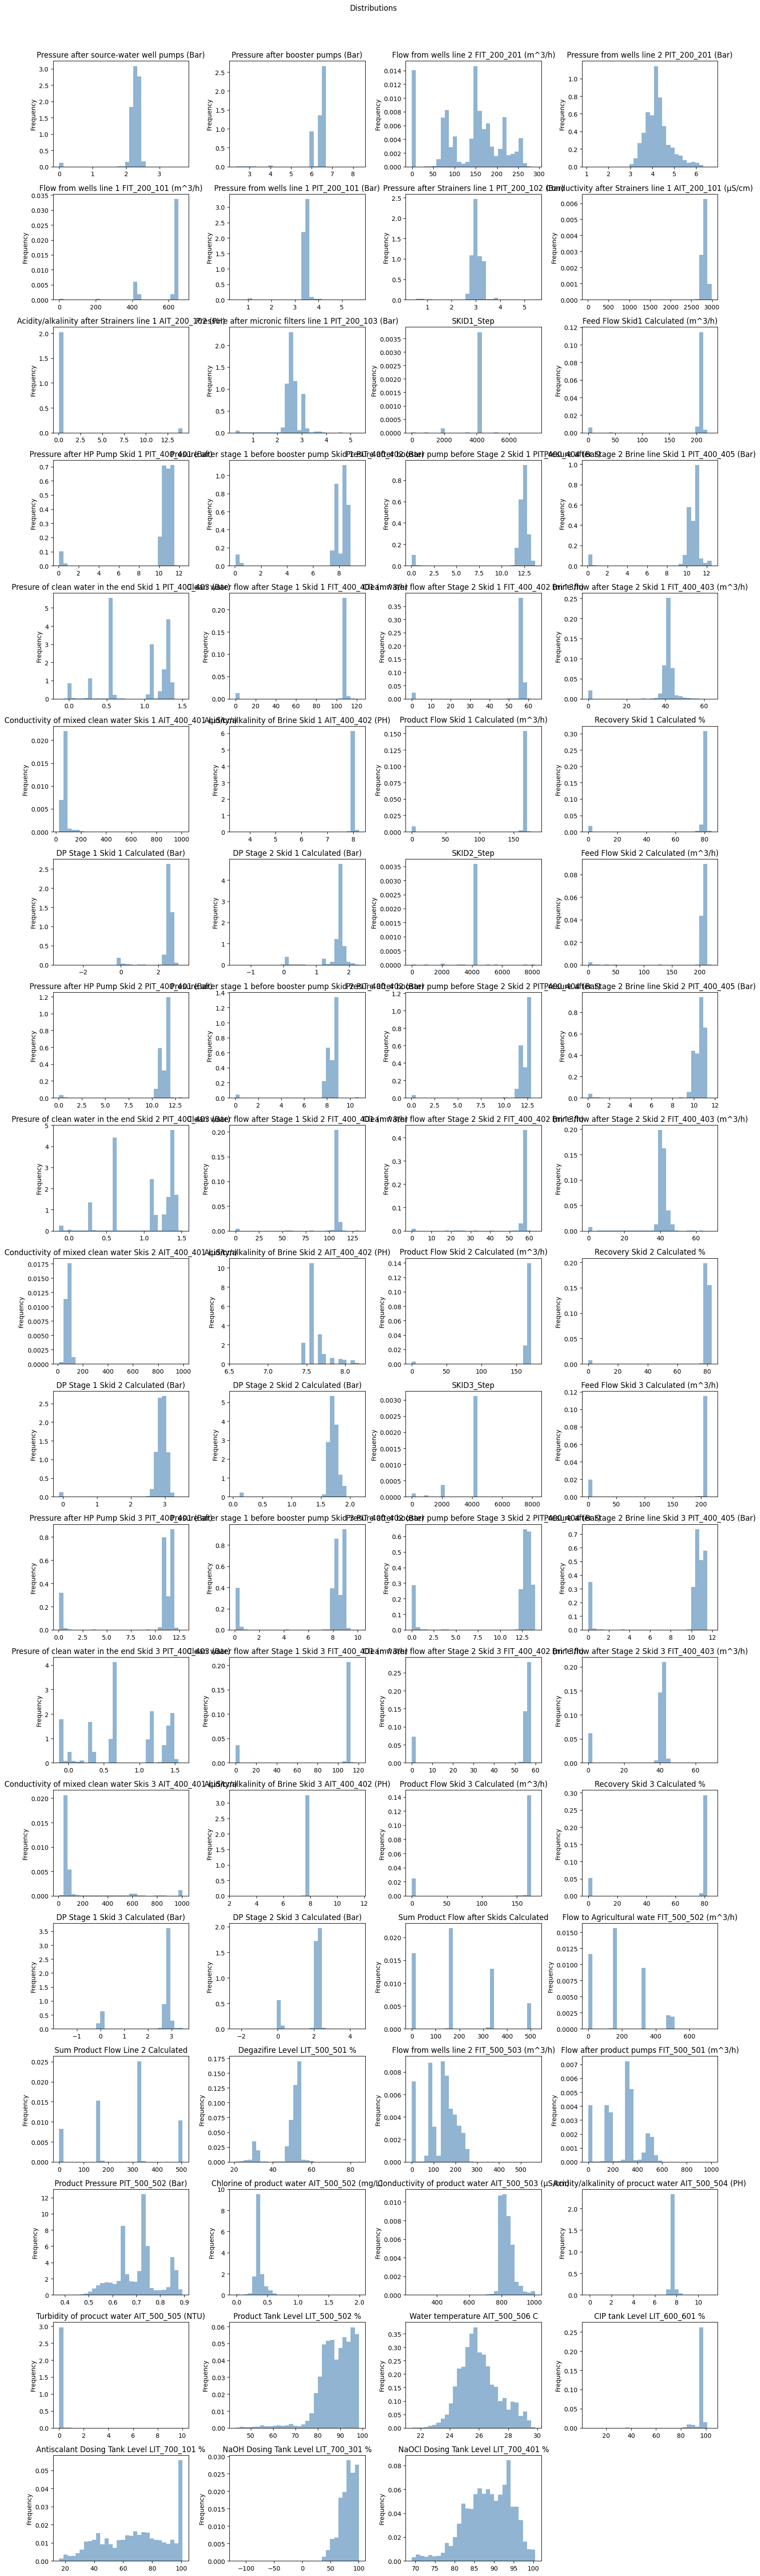

In [13]:
# Plot histogram and KDE (Kernel Density Estimate) for each numeric column in a grid layout
plot_distributions(df)

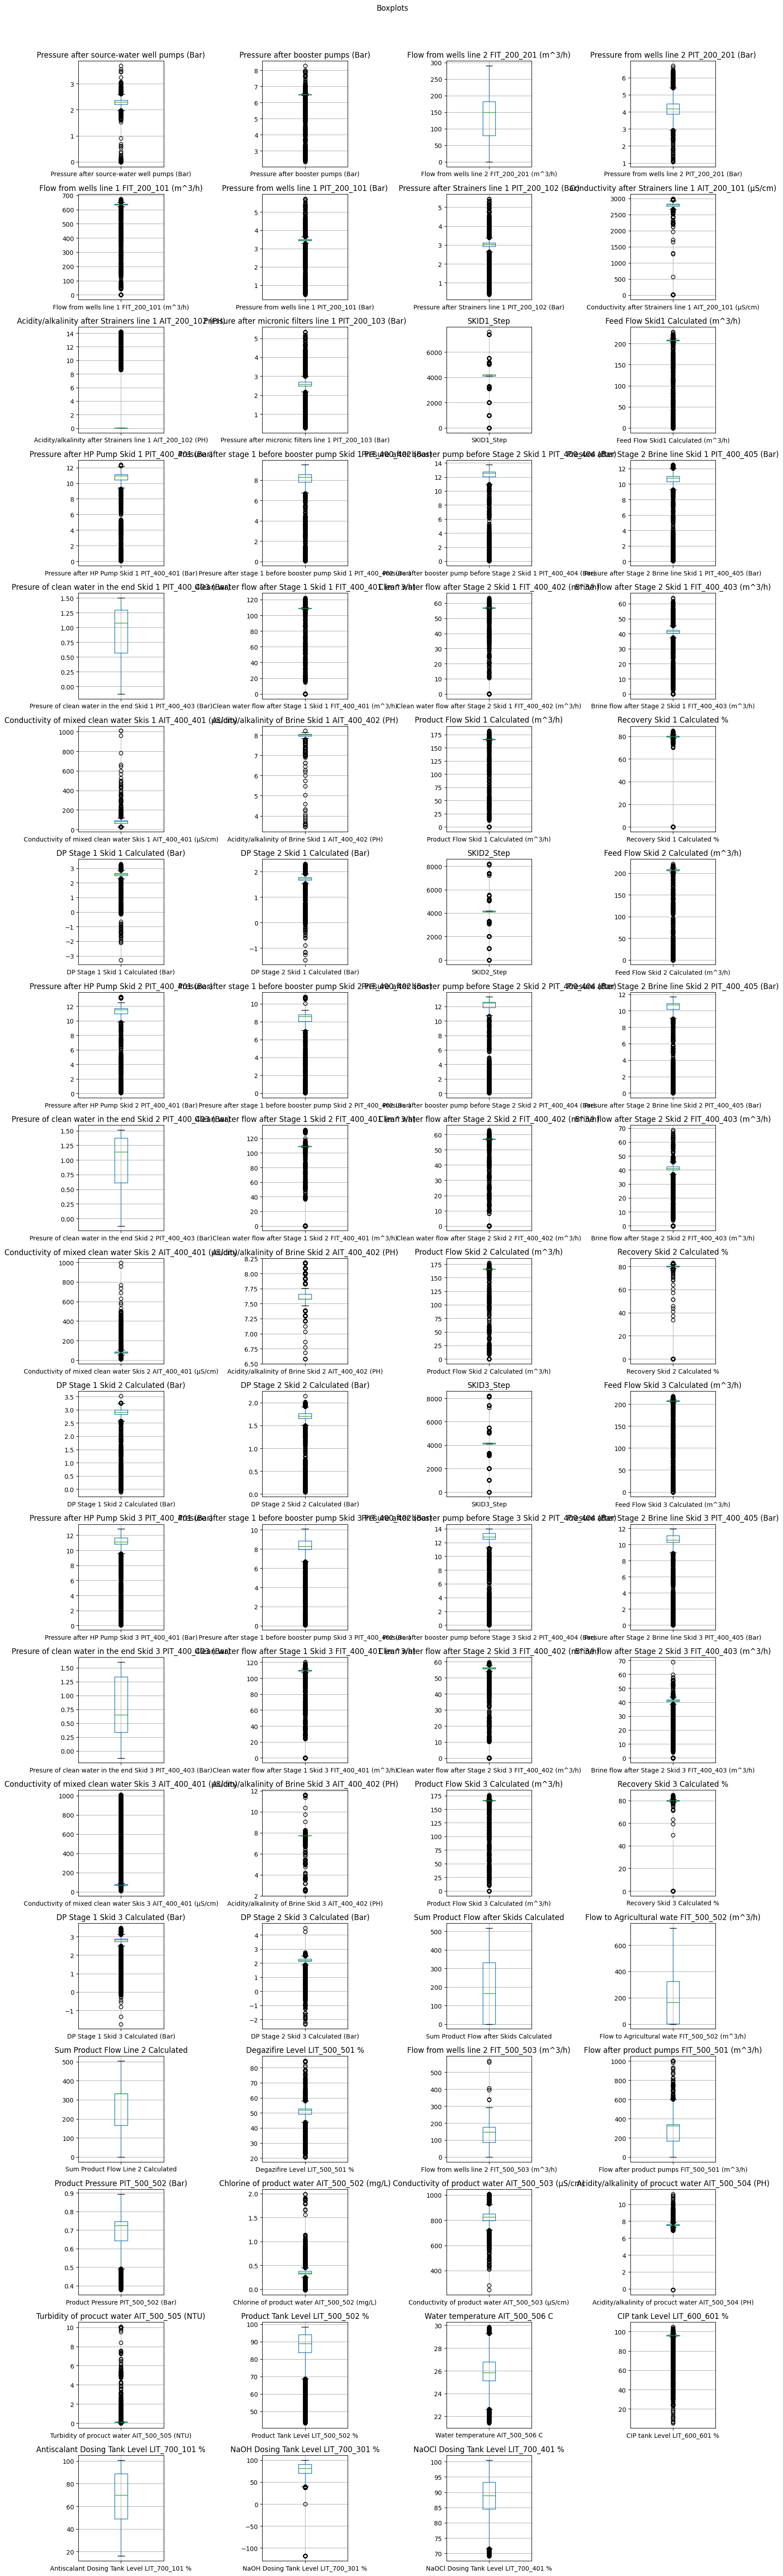

In [14]:
# Plot a boxplot for each numeric column to visualize spread and outliers
plot_boxplots(df)

## Correlations

(114218, 75)
(75, 75)


AttributeError: 'Axes' object has no attribute 'xticks'

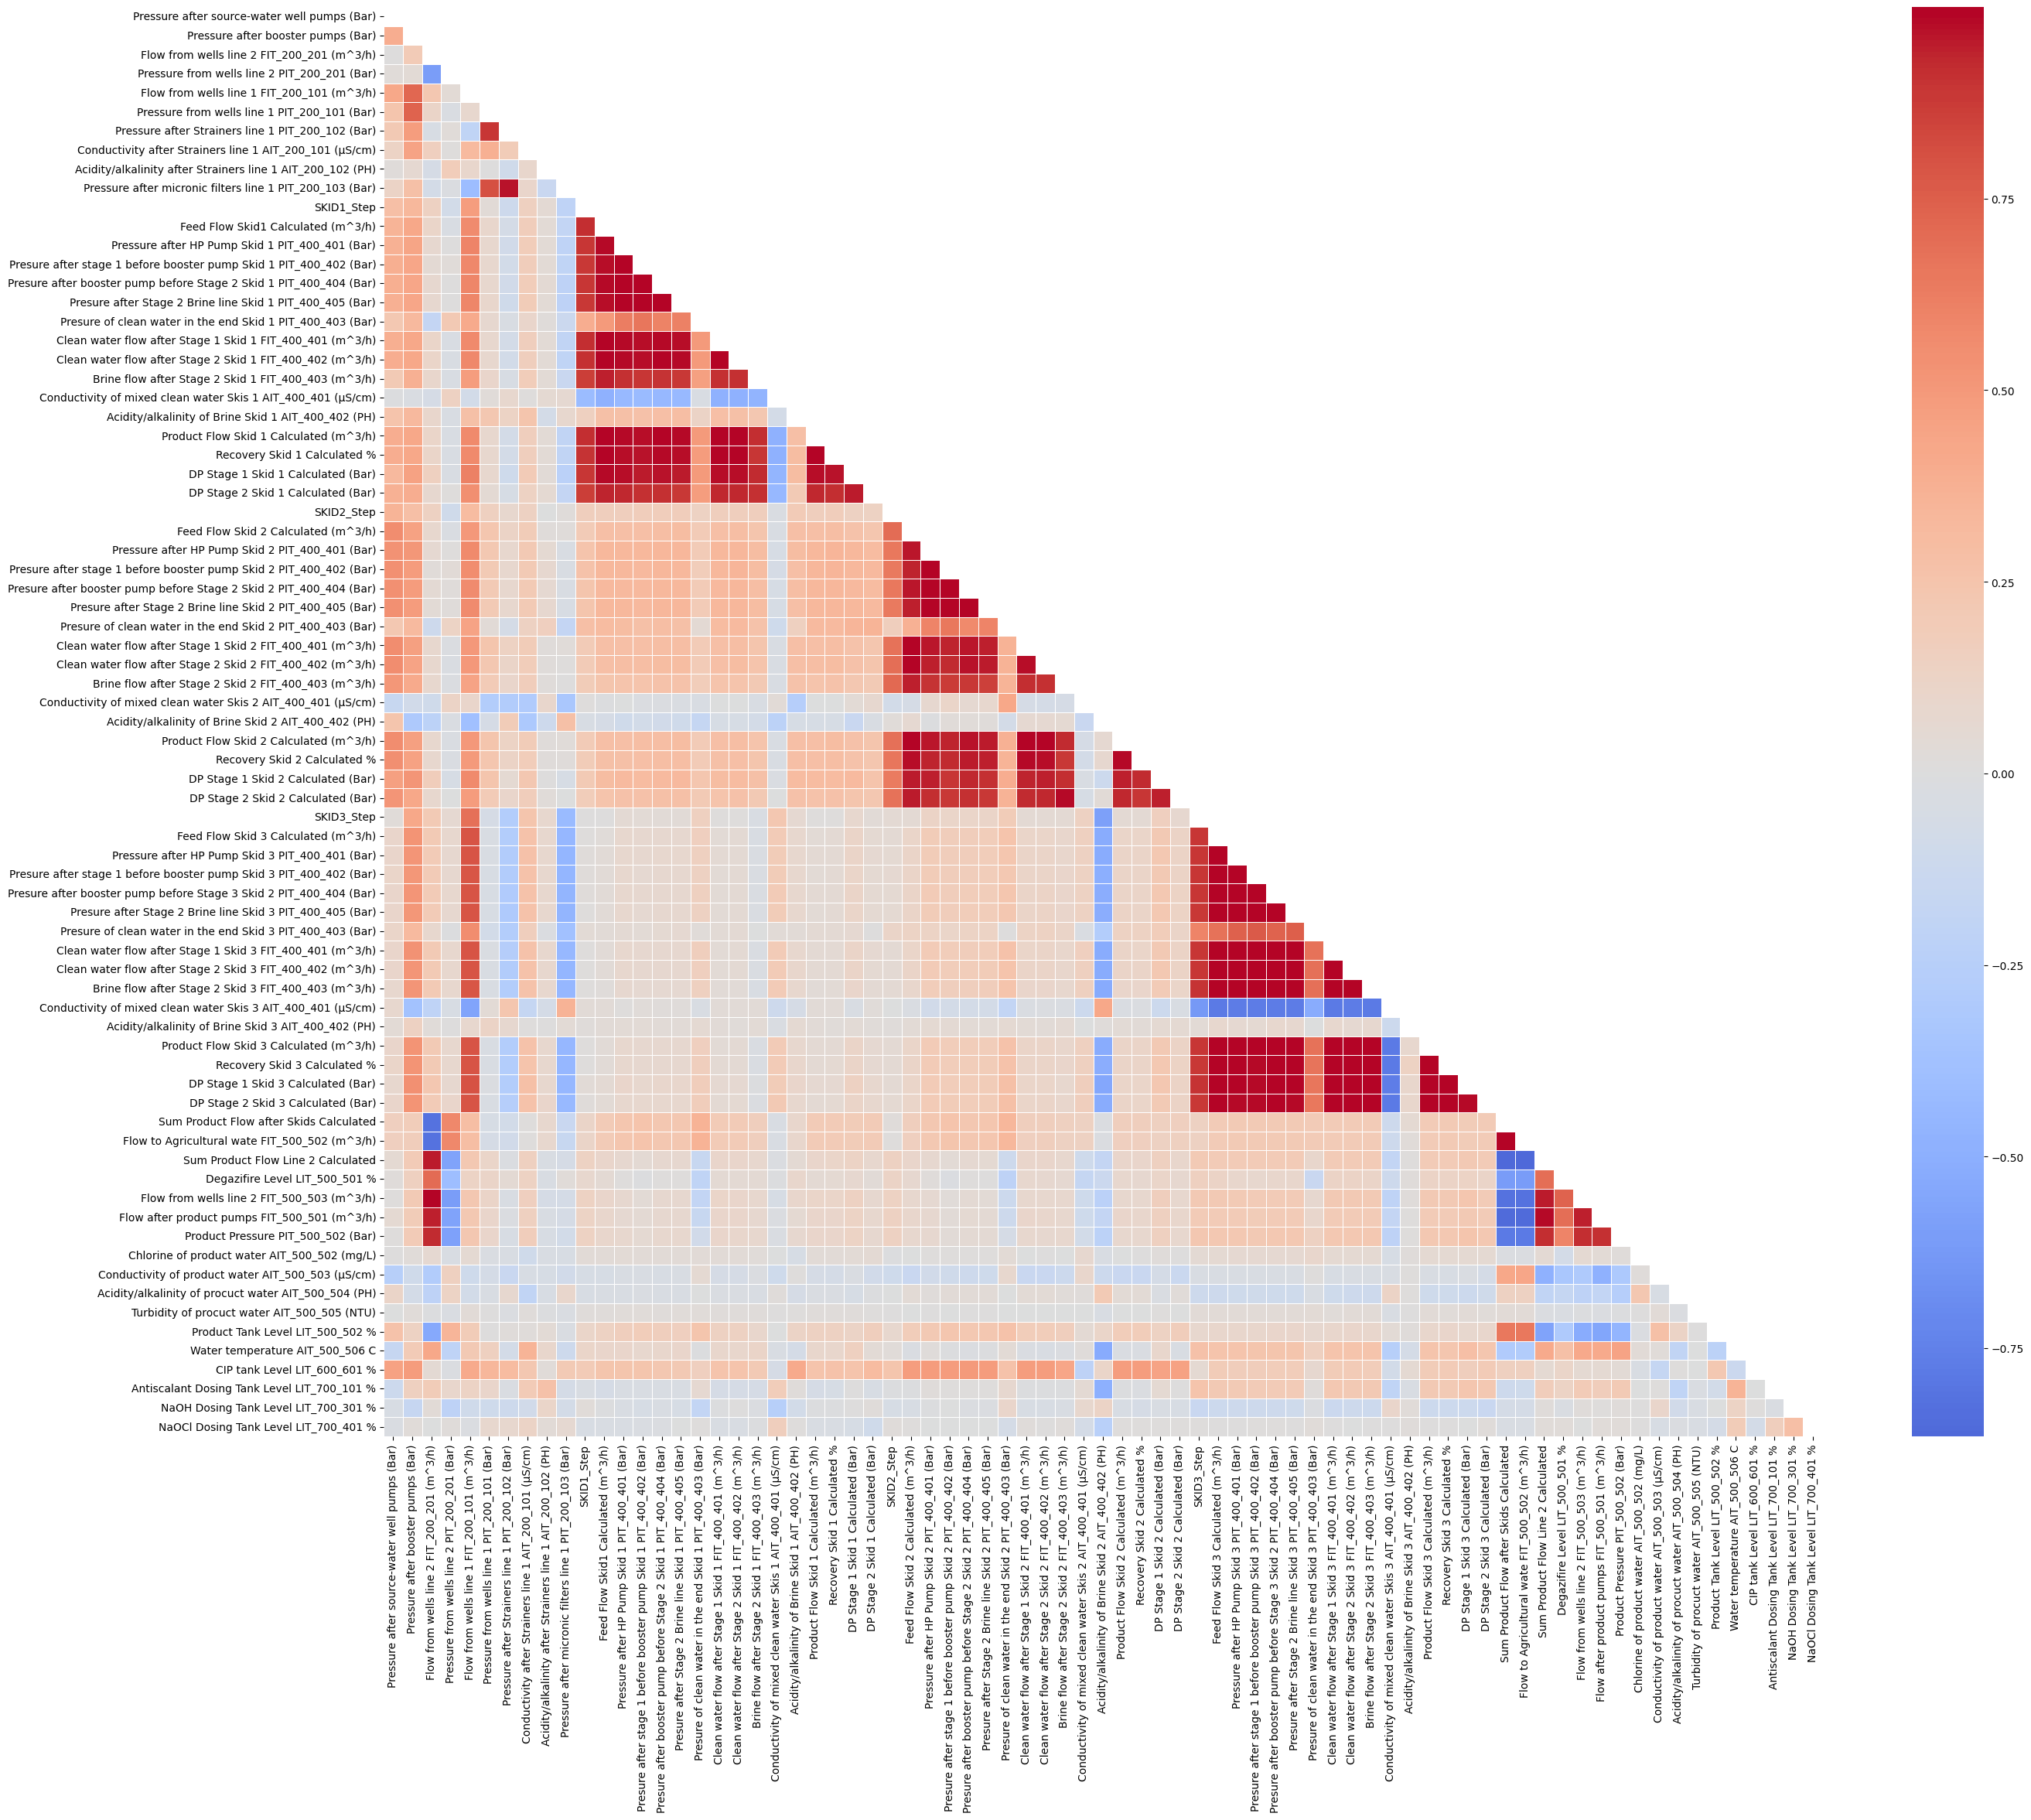

In [15]:
# Plot a lower-triangle correlation heatmap for all numeric columns
correlation_matrix(df, annot = False)
top_correlations(df, n = 20)